# coding attention machenism 

In [44]:
import torch

In [45]:
import torch
inputs = torch.tensor(
  [[0.43, 0.15, 0.89], # Your    (x^1)
   [0.55, 0.87, 0.66], # journey (x^2)
   [0.57, 0.85, 0.64], # starts  (x^3)
   [0.22, 0.58, 0.33], # with    (x^4)
   [0.77, 0.25, 0.10], # one     (x^5)
   [0.05, 0.80, 0.55]] # step    (x^6)
)

calculating the dot product with respect to `(x^2)` for all 

the first intermediate step, computing the
attention scores `W` between the query x(2) and all other input elements as a dot product

In [46]:
query = inputs[1]
attn_scores_2 = torch.empty(inputs.shape[0])
for i, x_i in enumerate(inputs):
    attn_scores_2[i] += torch.dot(x_i,query)
print(attn_scores_2) 

tensor([0.9544, 1.4950, 1.9934, 1.1607, 1.0490, 1.4272])


next we will normalize the `W` attention score that sum to 1

lets use `softmax` function to normalize the value of attention score `W`

In [47]:
def softmax(x):
    return torch.exp(x) / torch.exp(x).sum(dim = 0)

attn_weights_2 = softmax(attn_scores_2)
print("attention_sore:",attn_weights_2)
print("sum:",attn_weights_2.sum())

attention_sore: tensor([0.1055, 0.1812, 0.2983, 0.1297, 0.1160, 0.1693])
sum: tensor(1.)


In [48]:
query = inputs[1]
context_vec_2 = torch.zeros(query.shape)
for i,x_i in enumerate(inputs):
 context_vec_2 += attn_weights_2[i]*x_i
print(context_vec_2)

tensor([0.4414, 0.6667, 0.5519])


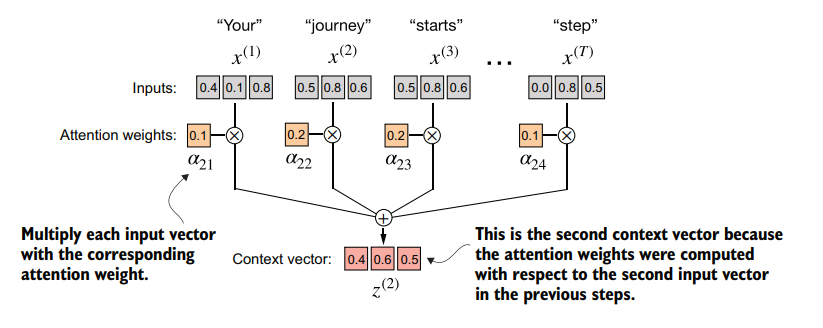

calculating the context vector z
(2) by multiplying the
embedded input tokens, x(i), with the corresponding attention weights and then summing the resulting vectors. Thus, context vector z
(2) is the weighted sum of all input vectors, obtained by multiplying each input vector by its corresponding attention weight:

## Computing attention weights for all input tokens

now lets compute an attention weights for all vectors 

In [49]:
attn_scores = torch.empty(6,6)
for i, x_i in enumerate(inputs):
    for j, x_j in enumerate(inputs):
        attn_scores[i,j] = torch.dot(x_i,x_j)

print(attn_scores)

tensor([[0.9995, 0.9544, 0.9422, 0.4753, 0.4576, 0.6310],
        [0.9544, 1.4950, 1.4754, 0.8434, 0.7070, 1.0865],
        [0.9422, 1.4754, 1.4570, 0.8296, 0.7154, 1.0605],
        [0.4753, 0.8434, 0.8296, 0.4937, 0.3474, 0.6565],
        [0.4576, 0.7070, 0.7154, 0.3474, 0.6654, 0.2935],
        [0.6310, 1.0865, 1.0605, 0.6565, 0.2935, 0.9450]])


lets apply normalization in it `softmax`

In [50]:
attn_weights = torch.softmax(attn_scores,dim= -1)
print(attn_weights)

tensor([[0.2098, 0.2006, 0.1981, 0.1242, 0.1220, 0.1452],
        [0.1385, 0.2379, 0.2333, 0.1240, 0.1082, 0.1581],
        [0.1390, 0.2369, 0.2326, 0.1242, 0.1108, 0.1565],
        [0.1435, 0.2074, 0.2046, 0.1462, 0.1263, 0.1720],
        [0.1526, 0.1958, 0.1975, 0.1367, 0.1879, 0.1295],
        [0.1385, 0.2184, 0.2128, 0.1420, 0.0988, 0.1896]])


In [51]:
all_context_vector = attn_weights @ inputs
print(all_context_vector)



tensor([[0.4421, 0.5931, 0.5790],
        [0.4419, 0.6515, 0.5683],
        [0.4431, 0.6496, 0.5671],
        [0.4304, 0.6298, 0.5510],
        [0.4671, 0.5910, 0.5266],
        [0.4177, 0.6503, 0.5645]])


implementing attention mechanism using `Q K V`

In [52]:
x_2 = inputs[1]  # 2 query of inputs 
in_d = inputs.shape[1]  # dimension of 2 query that is 3
out_d = 2

### Next, we initialize the three weight matrices Wq, Wk, and Wv 

In [53]:

torch.manual_seed(20)
W_Query = torch.nn.Parameter(torch.rand(in_d,out_d), requires_grad = False)
W_Key   = torch.nn.Parameter(torch.rand(in_d,out_d), requires_grad = False)
W_Value = torch.nn.Parameter(torch.rand(in_d,out_d), requires_grad = False)

Next, we compute the query, key, and value vectors:

In [54]:
query_2 = x_2  @ W_Query
key_2  = x_2 @ W_Key
value_2 = x_2 @ W_Value

print("=" * 50)
print(query_2)
print("=" * 50)
print(key_2)
print("=" * 50)
print(value_2)

tensor([1.1706, 0.9012])
tensor([0.6926, 1.0739])
tensor([1.4485, 0.9020])


In [55]:
keys = inputs @ W_Key 
values = inputs @ W_Value
print("keys.shape:", keys.shape)
print("values.shape:", values.shape)

keys.shape: torch.Size([6, 2])
values.shape: torch.Size([6, 2])


The unscaled attention score is computed
as a dot product between the query and
the key vectors.

In [56]:
# for input 2 only 
key_2 = keys[1]
attn_score_22 = query_2.dot(key_2)
print(attn_score_22)

tensor(1.7786)


In [57]:
# for all input values 
# @  is used for matrix multplications
attn_scores_2 = query_2 @ keys.T
print(attn_scores_2)

tensor([0.9749, 1.7786, 1.7714, 0.9828, 1.1440, 1.1159])


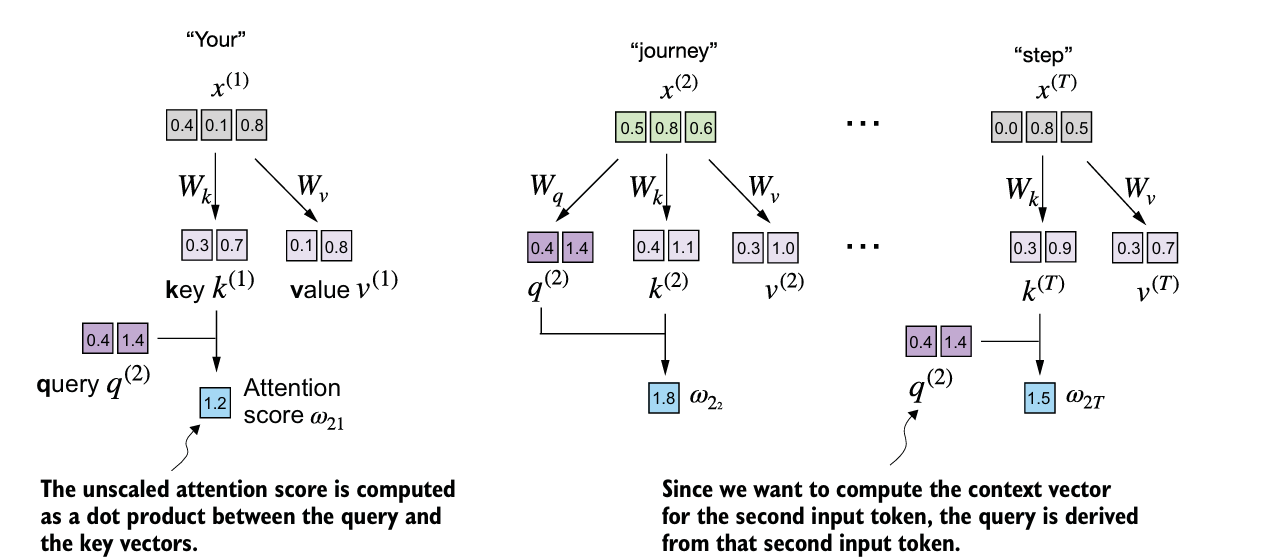

now we will go from attention score to attention weights 

In [58]:
d_k = keys.shape[-1]
attn_weights_2 = torch.softmax(attn_scores_2 / d_k**0.5, dim=-1)
print(attn_weights_2)

tensor([0.1289, 0.2275, 0.2264, 0.1296, 0.1453, 0.1424])


Now, the final step is to compute the context vectors, 

In [59]:
context_vec_2 = attn_weights_2 @ values
print(context_vec_2)

tensor([1.1374, 0.7007])


now lets do this for all vectors

# A compact Self-Attention Class 

In [60]:
import torch.nn as nn

class SelfAttention(nn.Module):
    def __init__(self,d_in,d_out):
        super().__init__()
        self.W_query = nn.Parameter(torch.rand(d_in,d_out))
        self.W_key   = nn.Parameter(torch.rand(d_in,d_out))
        self.W_value = nn.Parameter(torch.rand(d_in,d_out))
        
        
    def forward(self,x):
        keys = x @ self.W_key
        queries = x @ self.W_query
        values  = x @ self.W_value
        attn_scores = queries @ keys.T  # omega
        attn_weights = torch.softmax(
            attn_scores / keys.shape[-1]**0.5,dim = -1
        )
        context_vec = attn_weights @ values
        return context_vec         

In [ ]:
torch.manual_seed(20)
sa_v1 = SelfAttention(d_in=3,d_out=6)
print(sa_v1(inputs))

tensor([[0.8585, 1.2310, 0.7420, 0.9162, 0.8043, 0.8633],
        [0.8890, 1.2756, 0.7684, 0.9472, 0.8317, 0.8941],
        [0.8885, 1.2748, 0.7680, 0.9467, 0.8312, 0.8935],
        [0.8481, 1.2166, 0.7330, 0.9040, 0.7937, 0.8528],
        [0.8546, 1.2252, 0.7384, 0.9103, 0.7994, 0.8591],
        [0.8565, 1.2288, 0.7403, 0.9131, 0.8017, 0.8614]],
       grad_fn=<MmBackward0>)


# A compact Self-Attention Class 
## Using `nn.Linear`  

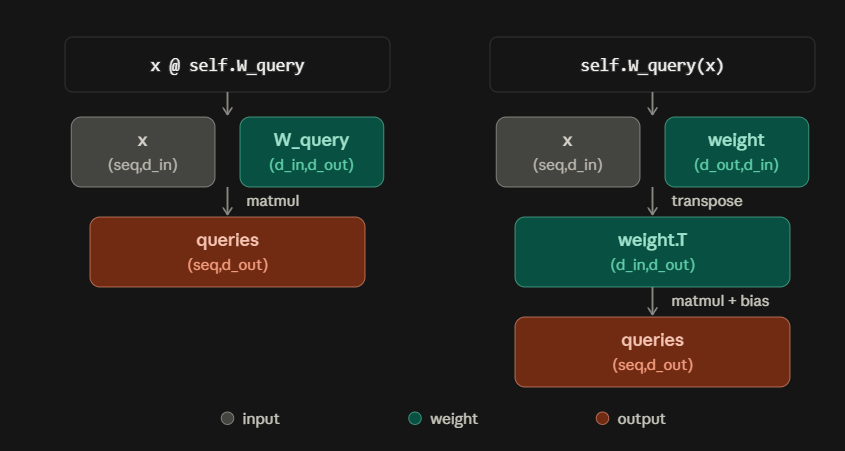

In [62]:
class SelfAttention_V2(nn.Module):
    def __init__(self,d_in,d_out,qkv_bias = False):
        super().__init__()
        self.W_query = nn.Linear(d_in,d_out,bias= qkv_bias)
        self.W_key   = nn.Linear(d_in,d_out,bias= qkv_bias)
        self.W_value = nn.Linear(d_in,d_out,bias= qkv_bias)
        
    def forward(self,x):
        keys = self.W_key(x)
        queries = self.W_query(x)
        values  = self.W_value(x)
        attn_scores = queries @ keys.T
        attn_weights = torch.softmax(
            attn_scores / keys.shape[-1]**0.5,dim = -1
        )
        
        context_vec = attn_weights @ values
        return context_vec

In [ ]:
d_in = inputs.shape[1]
d_out = 6

torch.manual_seed(20)
sa_v2 = SelfAttention_V2(d_in, d_out)
print(sa_v2(inputs))


tensor([[-0.2954, -0.0179,  0.2729,  0.1805,  0.1888,  0.0142],
        [-0.2975, -0.0187,  0.2750,  0.1815,  0.1901,  0.0144],
        [-0.2975, -0.0187,  0.2749,  0.1814,  0.1900,  0.0142],
        [-0.2938, -0.0173,  0.2722,  0.1802,  0.1882,  0.0156],
        [-0.2938, -0.0174,  0.2699,  0.1790,  0.1872,  0.0116],
        [-0.2948, -0.0176,  0.2740,  0.1812,  0.1892,  0.0172]],
       grad_fn=<MmBackward0>)


In [64]:
queries = sa_v2.W_query(inputs)
keys = sa_v2.W_key(inputs)
attn_scores = queries @ keys.T
attn_weights = torch.softmax(
    attn_scores / keys.shape[-1]**0.5,dim= -1
    
)

print(attn_weights)

tensor([[0.1665, 0.1771, 0.1766, 0.1585, 0.1570, 0.1643],
        [0.1687, 0.1814, 0.1806, 0.1542, 0.1526, 0.1624],
        [0.1681, 0.1812, 0.1805, 0.1546, 0.1530, 0.1626],
        [0.1701, 0.1747, 0.1743, 0.1590, 0.1582, 0.1638],
        [0.1558, 0.1738, 0.1736, 0.1652, 0.1637, 0.1678],
        [0.1768, 0.1768, 0.1762, 0.1547, 0.1540, 0.1615]],
       grad_fn=<SoftmaxBackward0>)


In [65]:
context_length = attn_scores.shape[0]
mask_simple = torch.tril(torch.ones(context_length, context_length))
print(mask_simple)

tensor([[1., 0., 0., 0., 0., 0.],
        [1., 1., 0., 0., 0., 0.],
        [1., 1., 1., 0., 0., 0.],
        [1., 1., 1., 1., 0., 0.],
        [1., 1., 1., 1., 1., 0.],
        [1., 1., 1., 1., 1., 1.]])


Now, we can multiply this mask with the attention weights to zero-out the values above
the diagonal

In [66]:
masked_simple = attn_weights*mask_simple
print(masked_simple)

tensor([[0.1665, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.1687, 0.1814, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.1681, 0.1812, 0.1805, 0.0000, 0.0000, 0.0000],
        [0.1701, 0.1747, 0.1743, 0.1590, 0.0000, 0.0000],
        [0.1558, 0.1738, 0.1736, 0.1652, 0.1637, 0.0000],
        [0.1768, 0.1768, 0.1762, 0.1547, 0.1540, 0.1615]],
       grad_fn=<MulBackward0>)


The third step is to renormalize the attention weights to sum up to 1 again in each
row. 

In [67]:
row_sums = masked_simple.sum(dim=-1, keepdim=True)
masked_simple_norm = masked_simple / row_sums
print(masked_simple_norm)

tensor([[1.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.4820, 0.5180, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.3173, 0.3420, 0.3407, 0.0000, 0.0000, 0.0000],
        [0.2508, 0.2576, 0.2570, 0.2345, 0.0000, 0.0000],
        [0.1873, 0.2089, 0.2086, 0.1985, 0.1967, 0.0000],
        [0.1768, 0.1768, 0.1762, 0.1547, 0.1540, 0.1615]],
       grad_fn=<DivBackward0>)


In [68]:
torch.manual_seed(20)
dropout = torch.nn.Dropout(0.5)
example = torch.ones(5,5)
print(dropout(example))

tensor([[2., 0., 0., 0., 0.],
        [0., 0., 0., 2., 2.],
        [0., 0., 0., 2., 0.],
        [2., 0., 0., 0., 0.],
        [2., 2., 2., 2., 2.]])


In [69]:
print(dropout(attn_weights))

tensor([[0.3330, 0.0000, 0.3533, 0.3169, 0.0000, 0.3285],
        [0.0000, 0.3627, 0.0000, 0.0000, 0.3053, 0.3248],
        [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.3252],
        [0.0000, 0.3493, 0.3485, 0.3180, 0.0000, 0.3276],
        [0.3117, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.3535, 0.0000, 0.3524, 0.0000, 0.0000, 0.0000]],
       grad_fn=<MulBackward0>)


# Implementing a compact causal attention class

 This class will then serve as a
template for developing `multi-head attention`, which is the final attention class we will
implement.

In [70]:
batch = torch.stack((inputs,inputs), dim=0)
print(batch.shape)

torch.Size([2, 6, 3])


In [74]:
# main class for attentions 
class Attention(nn.Module):
    def __init__(self,d_in,d_out,context_length,dropout,qkv_bias = False):
        super().__init__()
        self.d_out = d_out
        self.W_query = nn.Linear(d_in,d_out,bias= qkv_bias)
        self.W_key   = nn.Linear(d_in,d_out,bias= qkv_bias)
        self.W_value = nn.Linear(d_in,d_out,bias= qkv_bias)
        self.dropout = nn.Dropout(0.5)
        self.register_buffer(
            'mask',
            torch.triu(torch.ones(context_length,context_length),
                       diagonal=1)
            )
        
    def forward(self,x):
        b , num_tokens , d_in = x.shape
        keys = self.W_key(x)
        queries = self.W_query(x)
        values = self.W_value(x)
        
        """ dimensions 1 and 2, keeping the batch
            dimension at the first  position (0) """
            
        attn_scores = queries @ keys.transpose(1,2) 
        attn_scores.masked_fill_(
            self.mask.bool()[:num_tokens,:num_tokens],-torch.inf)
        
        attn_weights = torch.softmax(
            attn_scores / keys.shape[-1]**0.5 , dim = -1
        )
        
        attn_weights = self.dropout(attn_weights)
        
        context_vec = attn_weights @ values
        
        return context_vec

        

In [75]:
torch.manual_seed(123)
context_length = batch.shape[1]
ca = Attention(d_in, d_out, context_length, 0.0)
context_vecs = ca(batch)
print("context_vecs.shape:", context_vecs.shape)

context_vecs.shape: torch.Size([2, 6, 6])


# Extending single-head attention to multi-head attention

The term “multi-head” refers to dividing the attention mechanism into multiple
“heads,” each operating independently. In this context, a single causal attention module can be considered single-head attention, where there is only one set of attention
weights processing the input sequentially

___

*In code, we can achieve this by implementing a simple `MultiHeadAttentionWrapper` class that stacks multiple instances of our previously implemented `Attention` module.*

In [78]:
class MultiHeadAttentionWrapper(nn.Module):
    def __init__(self,d_in,d_out,context_length,dropout,num_head,qkv_bias = False):
        super().__init__()
        self.heads = nn.ModuleList(
            [Attention(
                d_in,d_out,context_length,dropout,qkv_bias
            )
             for _ in range(num_head)]
        )
    
    def forward(self,x):
        return torch.cat([head(x) for head in self.heads],dim= -1)

In [81]:
context_length = batch.shape[1]  # 6
d_in , d_out = 3,2

mha = MultiHeadAttentionWrapper(
    d_in,d_out,context_length,0.0,num_head= 2
)

context_vecs = mha(batch)

print(context_vecs)
print("context_vecs.shape:", context_vecs.shape)

tensor([[[ 0.7180,  0.6614, -0.7369, -1.2099],
         [ 0.3551,  0.3270, -0.7982, -1.1557],
         [ 0.5807,  0.1771, -0.2768, -0.3489],
         [ 0.2577, -0.0241, -0.4064, -0.5866],
         [ 0.3907,  0.1547, -0.3675, -0.5987],
         [ 0.1717, -0.0161, -0.1097, -0.2122]],

        [[ 0.7180,  0.6614,  0.0000,  0.0000],
         [ 0.8733,  0.2662,  0.0000,  0.0000],
         [ 0.9243,  0.1449, -0.5434, -0.7867],
         [ 0.1321, -0.0624, -0.4064, -0.5866],
         [ 0.1455,  0.1340, -0.4148, -0.5535],
         [ 0.5807,  0.1317, -0.2427, -0.4306]]], grad_fn=<CatBackward0>)
context_vecs.shape: torch.Size([2, 6, 4])


The first dimension of the resulting context_vecs tensor is 2 since we have two input
texts (the input texts are duplicated, which is why the context vectors are exactly the
same for those). The second dimension refers to the 6 tokens in each input. The third
dimension refers to the four-dimensional embedding of each token

# MultiHeadAttention Class

In [85]:
class MultiHeadAttention(nn.Module):
    def __init__(self, d_in,d_out,context_length,dropout,num_heads,qkv_bias = False):
        super().__init__()
        assert (d_out % num_heads == 0), \
            "d_out must be divisible by num_head"
            
        self.d_out = d_out
        self.num_heads = num_heads
        self.head_dim = d_out // num_heads  # Reduces the projection dim to match the desired output dim
        self.W_query = nn.Linear(d_in,d_out,bias=qkv_bias)
        self.W_key   = nn.Linear(d_in,d_out,bias=qkv_bias)
        self.W_value = nn.Linear(d_in,d_out,bias=qkv_bias)
        self.out_proj = nn.Linear(d_out, d_out)
        self.dropout = nn.Dropout(dropout)
        self.register_buffer(
            "mask",
            torch.triu(torch.ones(context_length,context_length),
                       diagonal=1)
        )
        
    def forward(self,x):
            b , num_tokens ,d_in = x.shape
            keys = self.W_key(x)
            queries = self.W_query(x)
            values  =  self.W_value(x)
            
            
            keys = keys.view(b,num_tokens,self.num_heads,self.head_dim)
            queries = queries.view(b,num_tokens,self.num_heads,self.head_dim)
            values = values.view(b,num_tokens,self.num_heads,self.head_dim)
            
            
            keys    =  keys.transpose(1,2)
            values  =  values.transpose(1,2)
            queries =  queries.transpose(1,2)
            
            attn_scores = queries @ keys.transpose(2,3)
            mask_bool = self.mask.bool()[:num_tokens,:num_tokens]
            
            attn_scores.masked_fill_(mask_bool,-torch.inf)
            
            attn_weights = torch.softmax(
                attn_scores / keys.shape[-1]**0.5 ,dim=-1
            )
            attn_weights = self.dropout(attn_weights)
            
            context_vec = (attn_weights @ values).transpose(1, 2)
            context_vec = context_vec.contiguous().view(b,num_tokens,self.d_out)
            context_vec = self.out_proj(context_vec)
            
            return context_vec

In [86]:
torch.manual_seed(20)
batch_size, context_length, d_in = batch.shape
d_out = 2
mha = MultiHeadAttention(d_in, d_out, context_length, 0.0, num_heads=2)
context_vecs = mha(batch)
print(context_vecs)
print("context_vecs.shape:", context_vecs.shape)

tensor([[[ 0.7625, -0.2444],
         [ 0.7549, -0.2715],
         [ 0.7522, -0.2798],
         [ 0.7384, -0.2996],
         [ 0.7335, -0.2956],
         [ 0.7284, -0.3097]],

        [[ 0.7625, -0.2444],
         [ 0.7549, -0.2715],
         [ 0.7522, -0.2798],
         [ 0.7384, -0.2996],
         [ 0.7335, -0.2956],
         [ 0.7284, -0.3097]]], grad_fn=<ViewBackward0>)
context_vecs.shape: torch.Size([2, 6, 2])
